In [ ]:

from halo_model.halos.base.mass_converter import NFWMassConverter
from halo_model.config.config import Config
from halo_model.halos.base.concentration.models.neto2007 import ConcentrationNeto2007
from halo_model.halos.base.r_vir.models.SO import R_virSO
from halo_model.halos.base.profile.models.nfw import ProfileNFW
from halo_model.halos.base.profile.models.stellar_truncated_powerlaw import ProfileStellarTruncatedPowerLaw
from halo_model.halos.base.profile.models.gas_cored_powerlaw import ProfileGasCoredPowerLaw

from halo_model.halos.base.shmr.models.moster2013 import SMHRMoster2013

import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import romb

from halo_model.algorithms.downhill_simplex import downhill_simplex
from halo_model.algorithms.fourier import fourier


In [2]:
cfg = Config()

In [3]:
R_vir = R_virSO(cfg)
c = ConcentrationNeto2007(cfg)
smhr = SMHRMoster2013(cfg, c)

dmprofile = ProfileNFW(c, R_vir)
stellarprofile = ProfileStellarTruncatedPowerLaw(cfg, smhr, c)
gasprofile = ProfileGasCoredPowerLaw(cfg, smhr, c)

Computing Fourier transform of gas profile...


r_vir: 0.5359982655676935
rho_bg: 77515979989.72624


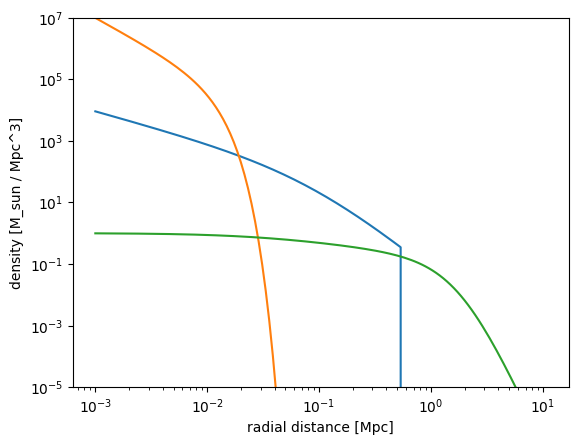

In [4]:
M = 1e13
z = 0
r_vir = R_virSO(cfg).R_vir(cfg.cosmo, M, z)
print("r_vir:", r_vir)
print("rho_bg:", cfg.cosmo.rho_m(z)*1e9)

rmin, rmax = 1e-3, 20*r_vir
Nr = 2**7
r_grid = np.geomspace(rmin, rmax, Nr)
rho_dm_grid = dmprofile.real(cfg.cosmo, r_grid, M, z)
rho_stellar_grid = stellarprofile.real(cfg.cosmo, r_grid, M, z)
rho_gas_grid = gasprofile.real(cfg.cosmo, r_grid, M, z)

plt.plot(r_grid, rho_dm_grid)
plt.plot(r_grid, rho_stellar_grid)
plt.plot(r_grid, rho_gas_grid)

plt.xscale("log")
plt.yscale("log")

plt.ylim(1e-5, 1e7)

plt.ylabel("density [M_sun / Mpc^3]")
plt.xlabel("radial distance [Mpc]")

plt.show()

# Compute fourier transform of NFW profile using np.fft and compare with analytical:



In [5]:
k_grid = np.geomspace(1e-1, 1e4, 50)

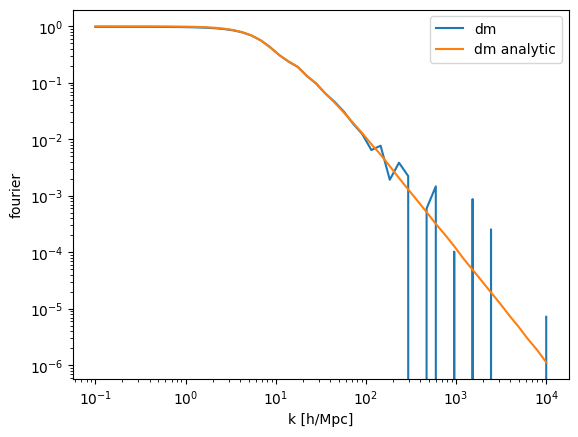

In [6]:
rho_dm = lambda r: dmprofile.real(cfg.cosmo, r, M, z)
fourier_dm_grid = np.array([fourier(k, rho_dm, rmin, rmax, Nr + 1) for k in k_grid])
plt.plot(k_grid, fourier_dm_grid, label='dm')
fourier_dm_analytic = [dmprofile.fourier(cfg.cosmo, k, M, z) for k in k_grid]
plt.plot(k_grid, fourier_dm_analytic, label = 'dm analytic')

plt.xscale("log")
plt.yscale("log")
plt.legend()

plt.ylabel("fourier")
plt.xlabel("k [h/Mpc]")

plt.show()

[415.91772811  -2.61737362   1.95302746]


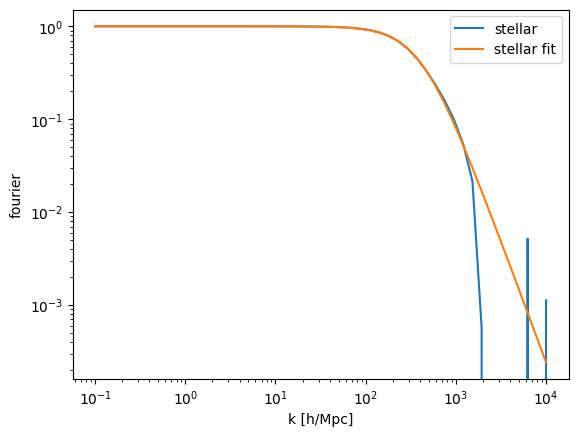

In [7]:
rho_stellar = lambda r: stellarprofile.real(cfg.cosmo, r, M, z)
fourier_stellar_grid = np.array([fourier(k, rho_stellar, rmin, rmax, Nr + 1) for k in k_grid])
fourier_stellar_grid /= fourier_stellar_grid[0]
plt.plot(k_grid, fourier_stellar_grid, label='stellar')

def fit_stellar(k, k_pivot, alpha, beta):
    return (1 + (k/k_pivot)**beta)**(alpha/beta)

def chi2_fit_stellar(args):
    fit_grid = fit_stellar(k_grid, *args)
    diff_grid = (fourier_stellar_grid - fit_grid)*(fourier_stellar_grid - fit_grid)
    return np.sum(diff_grid)

x_init = np.array(
    [
    (1.6/(0.015*r_vir), -1, 2.5),
    (1.6/(0.015*r_vir) * 1.1, -1, 2.5),
    (1.6/(0.015*r_vir), -1 * 1.1, 2.5),
    (1.6/(0.015*r_vir), -1, 2.5 * 1.1)
    ]
    )

args_opt_stellar = downhill_simplex(chi2_fit_stellar, x_init, relerr=1e-3)
print(args_opt_stellar)

plt.plot(k_grid, fit_stellar(k_grid, *args_opt_stellar), label = "stellar fit")

plt.xscale("log")
plt.yscale("log")
plt.legend()

plt.ylabel("fourier")
plt.xlabel("k [h/Mpc]")

plt.show()

/tmp/ipykernel_910895/2476641651.py:7: RuntimeWarning: invalid value encountered in power
  return (1 + (k/k_pivot)**beta)**(alpha/beta)


[ 2.44603893 -4.49684761  1.94422435]


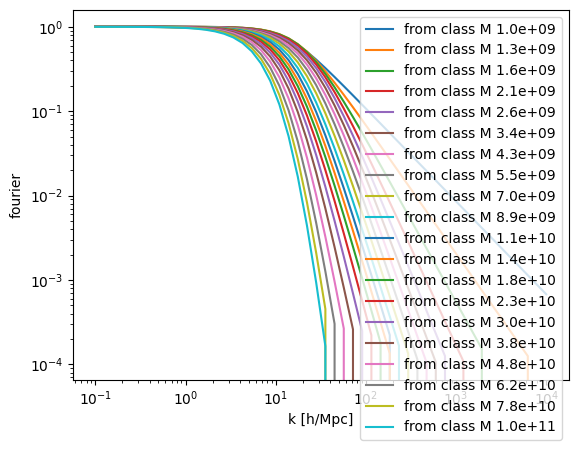

In [8]:
rho_gas = lambda r: gasprofile.real(cfg.cosmo, r, M, z)
fourier_gas_grid = np.array([fourier(k, rho_gas, rmin, rmax, Nr + 1) for k in k_grid])
fourier_gas_grid /= fourier_gas_grid[0]
# plt.plot(k_grid, fourier_gas_grid, label='gas')

def fit_gas(k, k_pivot, alpha, beta):
    return (1 + (k/k_pivot)**beta)**(alpha/beta)

def chi2_fit_gas(args):
    fit_grid = fit_gas(k_grid, *args)
    diff_grid = (fourier_gas_grid - fit_grid)*(fourier_gas_grid - fit_grid)
    return np.sum(diff_grid)

x_init = np.array(
    [
    (1.6/(0.015*r_vir), -1, 2.5),
    (1.6/(0.015*r_vir) * 1.1, -1, 2.5),
    (1.6/(0.015*r_vir), -1 * 1.1, 2.5),
    (1.6/(0.015*r_vir), -1, 2.5 * 1.1)
    ]
    )

args_opt_gas = downhill_simplex(chi2_fit_gas, x_init, relerr=1e-3)
print(args_opt_gas)

# plt.plot(k_grid, fit_gas(k_grid, *args_opt_gas)/ fourier_stellar_grid *fourier_stellar_grid[0])

for M in np.geomspace(1e9, 1e11, 20):
    plt.plot(k_grid, gasprofile.fourier(cfg.cosmo, k_grid, M, cfg.z), label=f'from class M {M:.1e}')
plt.xscale("log")
plt.yscale("log")
plt.legend()

plt.ylabel("fourier")
plt.xlabel("k [h/Mpc]")

plt.show()
